In [1]:
from sklearn.datasets import load_breast_cancer, fetch_california_housing
 
# Dataset A: Breast Cancer Wisconsin (classification)
# 569 patients(rows), 30 numeric features, target: 0 = malignant, 1 = benign

cancer = load_breast_cancer()
 
# Dataset B: California Housing (regression)
# 20,640 districts(rows), 8 numeric features, target: median house value
# Each row represents a neighborhood block group, not an individual house.

housing = fetch_california_housing(as_frame=True).frame


# Exercise 1 — Preprocessing Recap

In this exercise, I load the Wine dataset from scikit-learn and perform a complete preprocessing pipeline. The steps include exploratory data analysis, checking the dataset shape and statistics, splitting the data into training and testing sets, and scaling the numerical features using StandardScaler.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Wine dataset
wine = load_wine()

X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

# Basic EDA
print("Dataset shape:", X_wine.shape)
print("\nFirst 5 rows:")
print(X_wine.head())

print("\nSummary statistics:")
print(X_wine.describe())

print("\nMissing values:")
print(X_wine.isnull().sum())

print("\nTarget distribution:")
print(y_wine.value_counts().sort_index())

# Train/test split
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.2,
    random_state=42,
    stratify=y_wine
)

print("\nTraining shape:", Xw_train.shape)
print("Testing shape:", Xw_test.shape)

# Scaling
scaler_wine = StandardScaler()

Xw_train_scaled = scaler_wine.fit_transform(Xw_train)
Xw_test_scaled = scaler_wine.transform(Xw_test)

print("\nScaled training shape:", Xw_train_scaled.shape)
print("Scaled testing shape:", Xw_test_scaled.shape)

print("\nScaled training mean:")
print(np.round(Xw_train_scaled.mean(axis=0), 3))

print("\nScaled training standard deviation:")
print(np.round(Xw_train_scaled.std(axis=0), 3))

Dataset shape: (178, 13)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilu

In [ ]:
# Exercise 2 — Housing EDA

# The California Housing dataset contains 8 input features and the target variable MedHouseVal. I calculate the correlation of every feature with MedHouseVal and visualize the correlations using a heatmap. The two strongest predictors are identified using the absolute value of their correlation with the target.

SyntaxError: invalid syntax (479700483.py, line 3)

Correlation with MedHouseVal:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


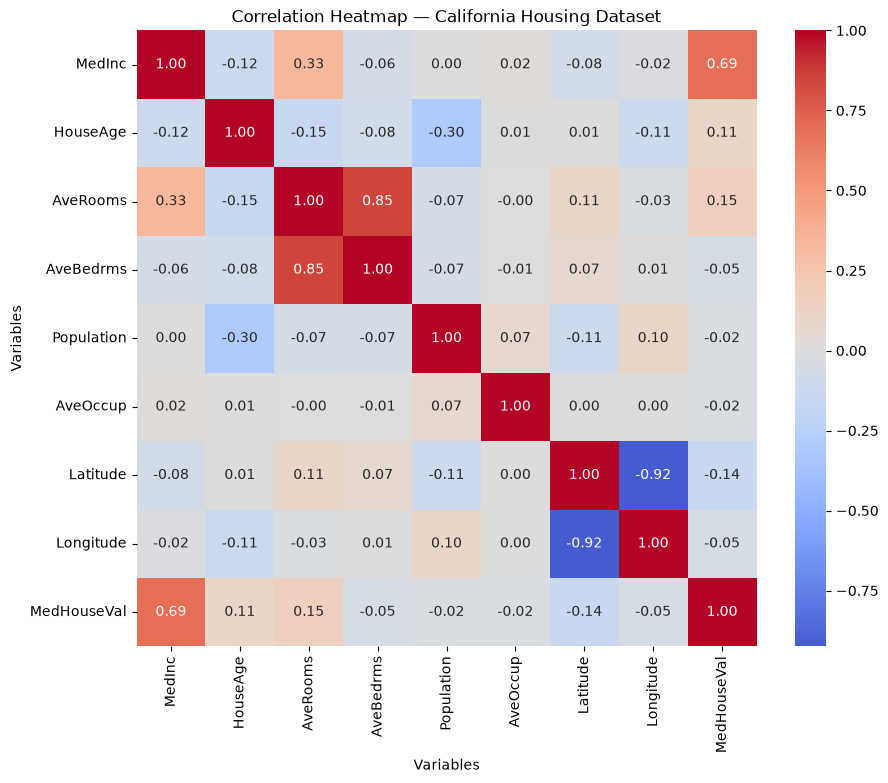


Two strongest predictors:
MedInc correlation = 0.688
AveRooms correlation = 0.152


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select all 8 housing features and target
housing_corr = housing.corr()

# Display correlations with target
print("Correlation with MedHouseVal:")
print(housing_corr["MedHouseVal"].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    housing_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap — California Housing Dataset")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()

# Find strongest two predictors
target_corr = housing_corr["MedHouseVal"].drop("MedHouseVal")
strongest = target_corr.abs().sort_values(ascending=False).head(2)

print("\nTwo strongest predictors:")
for feature in strongest.index:
    print(
        feature,
        "correlation =",
        round(target_corr[feature], 3)
    )

# Exercise 3 — OLS with Multiple Features

In Task 4, OLS was fitted using the single feature MedInc. Here, I refit the OLS model using all 8 Housing features. I compare the R² of the multi-feature model with the single-feature model to determine the improvement in explained variance.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# All 8 Housing features
X_housing = housing.drop(columns=["MedHouseVal"])
y_housing = housing["MedHouseVal"]

# Train/test split
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_housing,
    y_housing,
    test_size=0.2,
    random_state=42
)

# Multi-feature OLS
ols_multi = LinearRegression()
ols_multi.fit(Xh_train, yh_train)

# Predictions
yh_pred_multi = ols_multi.predict(Xh_test)

# R2
r2_multi = r2_score(yh_test, yh_pred_multi)

print("Multi-feature OLS R²:", round(r2_multi, 4))

# Single-feature MedInc model
X_single = housing[["MedInc"]]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_single,
    y_housing,
    test_size=0.2,
    random_state=42
)

ols_single = LinearRegression()
ols_single.fit(Xs_train, ys_train)

ys_pred = ols_single.predict(Xs_test)

r2_single = r2_score(ys_test, ys_pred)

print("Single-feature OLS R²:", round(r2_single, 4))

# Improvement
r2_improvement = r2_multi - r2_single

print("R² improvement:", round(r2_improvement, 4))
print("Percentage-point improvement:",
      round(r2_improvement * 100, 2), "%")

Multi-feature OLS R²: 0.5758
Single-feature OLS R²: 0.4589
R² improvement: 0.1169
Percentage-point improvement: 11.69 %


# Exercise 4 — RANSAC on a Noisier Feature

In this exercise, I use AveRooms instead of MedInc and compare ordinary least squares (OLS) with RANSAC regression. RANSAC is designed to reduce the influence of observations that do not fit the main linear relationship. I compare the slopes and R² values of both models.

In [8]:
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import r2_score

# Use AveRooms as the feature
X_rooms = housing[["AveRooms"]]
y_rooms = housing["MedHouseVal"]

# Train/test split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rooms,
    y_rooms,
    test_size=0.2,
    random_state=42
)

# OLS
ols_rooms = LinearRegression()
ols_rooms.fit(Xr_train, yr_train)

pred_ols_rooms = ols_rooms.predict(Xr_test)

# RANSAC
ransac_rooms = RANSACRegressor(
    estimator=LinearRegression(),
    random_state=42
)

ransac_rooms.fit(Xr_train, yr_train)

pred_ransac_rooms = ransac_rooms.predict(Xr_test)

# Results
ols_slope = ols_rooms.coef_[0]
ransac_slope = ransac_rooms.estimator_.coef_[0]

ols_r2_rooms = r2_score(yr_test, pred_ols_rooms)
ransac_r2_rooms = r2_score(yr_test, pred_ransac_rooms)

print("OLS slope:", round(ols_slope, 4))
print("RANSAC slope:", round(ransac_slope, 4))

print("\nOLS R²:", round(ols_r2_rooms, 4))
print("RANSAC R²:", round(ransac_r2_rooms, 4))

print("\nSlope difference:",
      round(abs(ols_slope - ransac_slope), 4))

OLS slope: 0.0768
RANSAC slope: 0.303

OLS R²: 0.0138
RANSAC R²: -0.3811

Slope difference: 0.2262


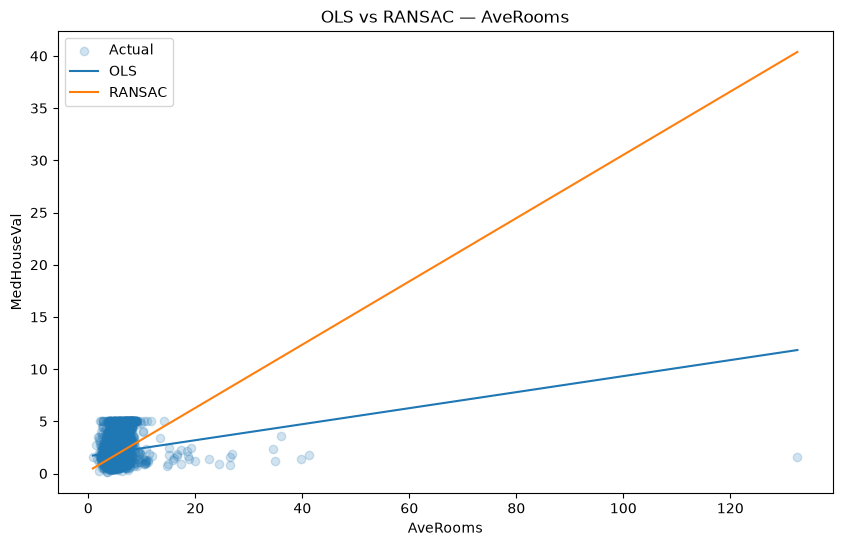

In [9]:
plt.figure(figsize=(10, 6))

plt.scatter(
    Xr_test["AveRooms"],
    yr_test,
    alpha=0.2,
    label="Actual"
)

sort_idx = np.argsort(Xr_test["AveRooms"].values)

x_sorted = Xr_test["AveRooms"].values[sort_idx]

plt.plot(
    x_sorted,
    pred_ols_rooms[sort_idx],
    label="OLS"
)

plt.plot(
    x_sorted,
    pred_ransac_rooms[sort_idx],
    label="RANSAC"
)

plt.title("OLS vs RANSAC — AveRooms")
plt.xlabel("AveRooms")
plt.ylabel("MedHouseVal")
plt.legend()
plt.show()

# Exercise 5 — Evaluating a Multi-Feature Model

The multi-feature OLS model from Exercise 3 is evaluated using RMSE and R². RMSE measures the typical prediction error in the target's units, while R² measures the proportion of target variation explained by the model. A residual plot is also produced to check the pattern of prediction errors.

Multi-feature OLS RMSE: 0.7456
Multi-feature OLS R²: 0.5758


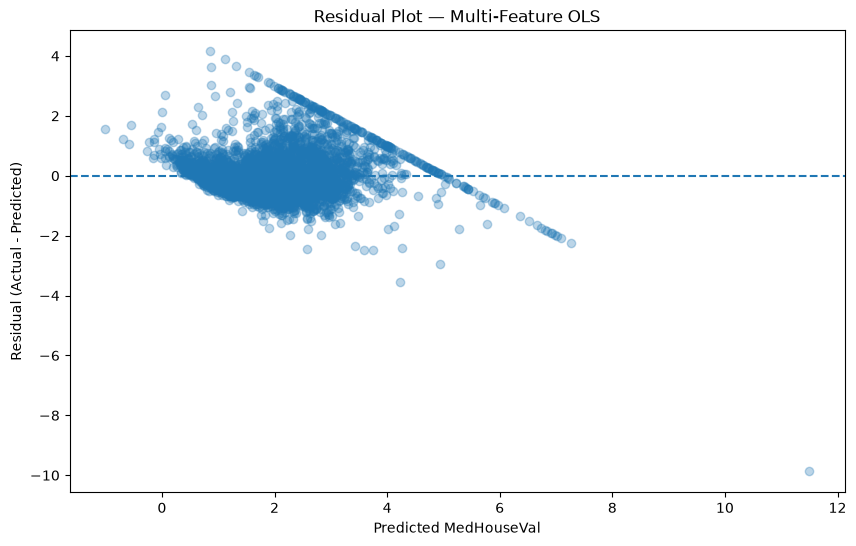

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Predictions from Exercise 3
yh_pred_multi = ols_multi.predict(Xh_test)

# RMSE
rmse_multi = np.sqrt(mean_squared_error(yh_test, yh_pred_multi))

# R²
r2_multi = r2_score(yh_test, yh_pred_multi)

print("Multi-feature OLS RMSE:", round(rmse_multi, 4))
print("Multi-feature OLS R²:", round(r2_multi, 4))

# Residuals
residuals = yh_test - yh_pred_multi

# Residual plot
plt.figure(figsize=(10, 6))

plt.scatter(
    yh_pred_multi,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot — Multi-Feature OLS")
plt.xlabel("Predicted MedHouseVal")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

# Exercise 6 — Gradient Descent with Regularization

L2 regularization adds a penalty for large weights to the gradient descent update. This encourages the model to keep its weights smaller. I test several penalty values and compare the final weight values. Larger penalty values should generally produce more strongly shrunk weights.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent_l2(
    X,
    y,
    learning_rate=0.01,
    epochs=1000,
    l2_penalty=0.0
):
    """
    Gradient Descent with L2 regularization.

    l2_penalty = 0 means no regularization.
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    # Add intercept column
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    # Initialize weights
    w = np.zeros(X_b.shape[1])

    n = len(y)

    for epoch in range(epochs):

        predictions = X_b @ w

        error = predictions - y

        # Gradient of MSE
        gradient = (2 / n) * X_b.T @ error

        # L2 penalty
        # Do not regularize the intercept
        l2_gradient = 2 * l2_penalty * w
        l2_gradient[0] = 0

        # Weight update
        w = w - learning_rate * (
            gradient + l2_gradient
        )

    return w

In [12]:
# Use one feature for easy comparison
X_gd = housing[["MedInc"]].values
y_gd = housing["MedHouseVal"].values

# Scale feature to make gradient descent stable
X_gd = (
    X_gd - X_gd.mean()
) / X_gd.std()

penalties = [0, 0.01, 0.1, 1, 10]

final_weights = []

for penalty in penalties:

    w_final = gradient_descent_l2(
        X_gd,
        y_gd,
        learning_rate=0.01,
        epochs=2000,
        l2_penalty=penalty
    )

    final_weights.append(w_final)

    print(
        "L2 penalty:",
        penalty,
        " | Intercept:",
        round(w_final[0], 4),
        " | Weight:",
        round(w_final[1], 4)
    )

L2 penalty: 0  | Intercept: 2.0686  | Weight: 0.794
L2 penalty: 0.01  | Intercept: 2.0686  | Weight: 0.7861
L2 penalty: 0.1  | Intercept: 2.0686  | Weight: 0.7218
L2 penalty: 1  | Intercept: 2.0686  | Weight: 0.397
L2 penalty: 10  | Intercept: 2.0686  | Weight: 0.0722


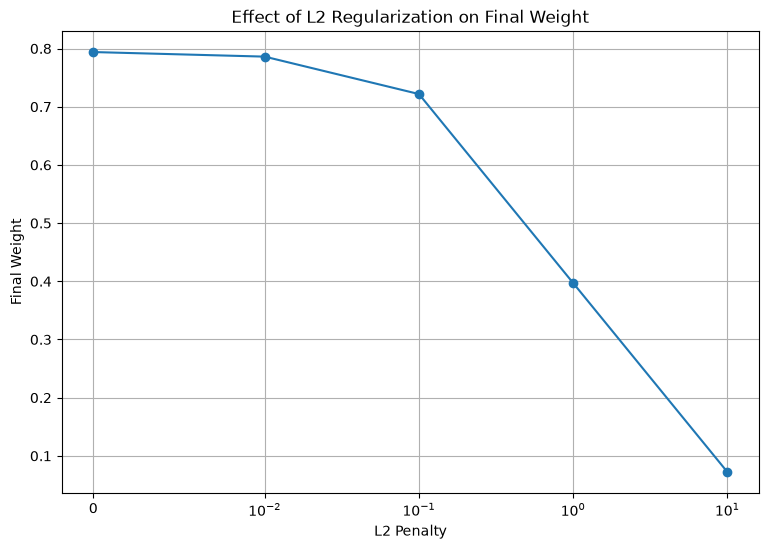

In [13]:
weights_only = [
    w[1] for w in final_weights
]

plt.figure(figsize=(9, 6))

plt.plot(
    penalties,
    weights_only,
    marker="o"
)

plt.title("Effect of L2 Regularization on Final Weight")
plt.xlabel("L2 Penalty")
plt.ylabel("Final Weight")
plt.xscale("symlog", linthresh=0.01)
plt.grid(True)
plt.show()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns